# Associer des données avec Pandas : les jointures

Lino Galiana  
2026-07-20

<div class="badge-container"><div class="badge-text">Pour essayer les exemples présents dans ce tutoriel :</div><a href="https://github.com/linogaliana/python-datascientist-notebooks/blob/main/notebooks/manipulation/02_pandas_joins.ipynb" class="badge" target="_blank" rel="noopener"><img src="https://img.shields.io/static/v1?logo=github&label=&message=View%20on%20GitHub&color=181717" alt="View on GitHub"></a>
<a href="https://datalab.sspcloud.fr/launcher/ide/vscode-python?autoLaunch=true&name=«02_pandas_joins»&init.personalInit=«https%3A%2F%2Fraw.githubusercontent.com%2Flinogaliana%2Fpython-datascientist%2Fmain%2Fsspcloud%2Finit-vscode.sh»&init.personalInitArgs=«manipulation%2002_pandas_joins»" class="badge" target="_blank" rel="noopener"><img src="https://custom-icon-badges.demolab.com/badge/SSP%20Cloud-Lancer_avec_VSCode-blue?logo=vsc&logoColor=white" alt="Onyxia"></a>
<a href="https://datalab.sspcloud.fr/launcher/ide/jupyter-python?autoLaunch=true&name=«02_pandas_joins»&init.personalInit=«https%3A%2F%2Fraw.githubusercontent.com%2Flinogaliana%2Fpython-datascientist%2Fmain%2Fsspcloud%2Finit-jupyter.sh»&init.personalInitArgs=«manipulation%2002_pandas_joins»" class="badge" target="_blank" rel="noopener"><img src="https://img.shields.io/badge/SSP%20Cloud-Lancer_avec_Jupyter-orange?logo=Jupyter&logoColor=orange" alt="Onyxia"></a>
<a href="https://colab.research.google.com/github/linogaliana/python-datascientist-notebooks-colab//blob/main//notebooks/manipulation/02_pandas_joins.ipynb" class="badge" target="_blank" rel="noopener"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"></a>
<a href="https://codespaces.new/linogaliana/python-datascientist-notebooks?quickstart=1&ref=main" class="badge" target="_blank" rel="noopener"><img src="https://github.com/codespaces/badge.svg" alt="Open in GitHub Codespaces"></a><br></div>

> **None**
>
> <div class="callout callout-style-default callout-note callout-titled">
> <div class="callout-header d-flex align-content-center">
> <div class="callout-icon-container">
> <i class="callout-icon"></i>
> </div>
> <div class="callout-title-container flex-fill">
> Note
> </div>
> </div>
> <div class="callout-body-container callout-body">
>
> Ceci est la version française 🇫🇷 de ce chapitre, pour voir la version anglaise rendez-vous sur <a href="https://pythonds.linogaliana.fr//home/runner/work/python-datascientist/python-datascientist/en/content/manipulation/02_pandas_joins.qmd">le site du cours</a>.
>
> </div>
> </div>


<div class="callout callout-style-default callout-tip callout-titled">
<div class="callout-header d-flex align-content-center">
<div class="callout-icon-container">
<i class="callout-icon"></i>
</div>
<div class="callout-title-container flex-fill">
Compétences à l’issue de ce chapitre
</div>
</div>
<div class="callout-body-container callout-body">

-   Récupérer un jeu de données officiel de l’Insee ;
-   Comprendre la logique d’une jointure et savoir choisir le type de pivot adapté ;
-   Associer plusieurs `DataFrames` à partir de caractéristiques communes ;
-   Connaître les identifiants permettant de relier entre elles de multiples sources françaises.

</div>
</div>

Les exercices de mise en pratique dans ce tutoriel sont assez tardifs, une fois les principes des jointures et des identifiants passés en revue : voir <a href="#tip-cle-jointure" class="quarto-xref">Tip 6.1</a> et <a href="#tip-empreinte-carbone" class="quarto-xref">Tip 6.2</a>.

# 1. Introduction

Le [chapitre d’introduction à `Pandas`](../../content/manipulation/02_pandas_intro.qmd) a permis de présenter le principe de données organisées sous une forme de *DataFrame* et la praticité de l’écosystème `Pandas` pour effectuer des opérations simples sur un jeu de données.

L’un des apports des outils modernes de *data science*, notamment `Pandas`, est la simplicité par laquelle ils permettent de restructurer des sources pour travailler sur plusieurs données sur un projet.

Il est rare de travailler exclusivement sur une source brute. Un jeu de données prend généralement de la valeur lorsqu’il est comparé à d’autres sources. Pour des chercheurs, cela permettra de contextualiser l’information présente dans une source en la comparant ou en l’associant à d’autres sources. Pour des *data scientists* dans le secteur privé, il s’agira souvent d’associer des informations sur une même personne dans plusieurs bases clientes ou comparer les clients entre eux.

Effectuer ce travail de manière simple, fiable et efficace est indispensable pour les *data scientists* tant cette tâche est courante. Heureusement `Pandas` permet de faire cela très bien avec des données structurées. Nous verrons dans les prochains chapitres, mais aussi dans l’ensemble de la [partie sur le traitement des données textuelles](../../content/nlp/index.qmd), comment faire avec des données moins structurées.

Grâce à ce travail d’enrichissement, nous serons en mesure, dans le [prochain chapitre](../../content/manipulation/02_pandas_stats.qmd), d’approfondir notre compréhension d’un phénomène réel par le biais de statistiques descriptives fines. Cela est une étape indispensable avant de basculer vers la [statistique inférentielle](https://fr.wikipedia.org/wiki/Inf%C3%A9rence_statistique#:~:text=L'inf%C3%A9rence%20statistique%20est%20l,%3A%20la%20probabilit%C3%A9%20d'erreur.), l’approche qui consiste à formaliser et généraliser des liens de corrélation ou de causalité entre des caractéristiques observées et un phénomène.

## 1.1 Environnement

Le chapitre précédent utilisait quasi exclusivement la librairie `Pandas` car nous avions une source prête à l’emploi. Dans ce chapitre, nous aurons besoin d’aller chercher des données un peu moins accessibles : cela nécessitera un peu plus de travail.

Les principes généraux de la récupération de données seront présentés dans le [chapitre consacré aux API](../../content/manipulation/04c_API_TP.qmd). Nous donnerons directement le code de récupération des données dans ce chapitre pour pouvoir se consacrer au coeur de notre problème: associer ces différentes données entre-elles.

Les premiers *packages* indispensables pour démarrer ce chapitre sont les suivants:


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

Pour obtenir des résultats reproductibles, on peut fixer la racine du générateur
pseudo-aléatoire.


In [ ]:
np.random.seed(123)

## 1.2 Données utilisées

Ce tutoriel continue l’exploration du jeu de données du chapitre précédent:

-   Les émissions de gaz à effet de serre estimées au niveau communal par l’ADEME. Le jeu de données est
    disponible sur [data.gouv](https://www.data.gouv.fr/fr/datasets/inventaire-de-gaz-a-effet-de-serre-territorialise/#_)
    et requêtable directement dans `Python` avec
    [cet url](https://data.ademe.fr/data-fair/api/v1/datasets/igt-pouvoir-de-rechauffement-global/convert) ;

Les problématiques d’enrichissement de données (association d’une source à une autre à partir de caractéristiques communes) seront présentées à partir de deux sources produites par l’Insee:

-   Le [code officiel géographique](https://www.insee.fr/fr/information/6800675), un référentiel produit par l’Insee utilisé pour identifier les communes à partir d’un code unique, contrairement au code postal ;
-   Les données [*Filosofi*](https://www.insee.fr/fr/metadonnees/source/serie/s1172), une source sur les revenus des Français à une échelle spatiale fine construite par l’Insee à partir des déclarations fiscales et d’informations sur les prestations sociales. En l’occurrence, nous allons utiliser, au niveau communal, des données de revenu médian et la population totale[1]. Cela nous aidera à calculer de nouveaux indicateurs d’émissions et à les interpréter.

Pour importer ces données, nous allons directement interroger l’API
[`Melodi`](https://api.insee.fr/catalogue/), le nouveau point d’entrée mis à disposition par l’Insee pour diffuser ses principales sources de données, dont fait partie *Filosofi*.


<div class="callout callout-style-default callout-note callout-titled">
<div class="callout-header d-flex align-content-center">
<div class="callout-icon-container">
<i class="callout-icon"></i>
</div>
<div class="callout-title-container flex-fill">
Récupérer des données open data produites par l’Insee
</div>
</div>
<div class="callout-body-container callout-body">

Une précédente version de ce tutoriel s’appuyait sur le *package* communautaire [`pynsee` ](https://github.com/InseeFrLab/pynsee) qui simplifie l’accès aux données officielles de l’Insee.

Cependant, les sources qui nous sont ici utiles ont été intégrées dans une nouvelle API de l’Insee nommée `Melodi`. Comme c’est un produit officiel de l’offre de diffusion de l’Insee, on va privilégier celle-ci. L’inconvénient est que nous n’avons pas, comme avec [`pynsee` ](https://github.com/InseeFrLab/pynsee), un *dataframe* prêt à l’emploi. Le code de préparation des données sera donc un peu plus complexe.

L’API renvoie des données structurées au format `JSON`: chaque
observation associe des dimensions (par exemple `GEO` pour la zone géographique ou `TIME_PERIOD` pour la période) à une valeur (`OBS_VALUE_NIVEAU`). Plus d’éléments sur l’exploitation de JSON via Python seront proposés dans le [chapitre consacré aux API](../../content/manipulation/04c_API_TP.qmd).

Chaque source dispose d’un identifiant unique (par exemple `DS_FILOSOFI_CC` pour les données Filosofi communales, `DS_POPULATIONS_HISTORIQUES` pour les populations légales). Le point d’entrée principal est de la forme `https://api.insee.fr/melodi/data/{identifiant}`, que l’on peut filtrer
par dimension (zone géographique, période, indicateur…). La structure de chaque fichier dépend de la source demandée. Il y a donc généralement un travail propre à chaque source à mettre en oeuvre.

<details>

<summary>

Explorer la structure d’une source

</summary>

Pour connaître la structure d’une source (dimensions, indicateurs
disponibles…), on peut consulter ses métadonnées, également disponibles au format `JSON` :

``` python
import requests
requests.get("https://api.insee.fr/melodi/catalog/DS_FILOSOFI_CC").json()
```

La liste des sources disponibles sur l’API Melodi est quant à elle consultable sur le [portail des API](https://catalogue-donnees.insee.fr/fr/catalogue/recherche) de l’Insee.

</details>

</div>
</div>

# 2. Récupération des jeux de données

## 2.1 Données d’émission de l’Ademe

Comme expliqué au chapitre précédent, ces données peuvent être importées très simplement avec `Pandas`

[1] Pour les données démographiques, on utilise directement les [populations légales](https://www.insee.fr/fr/information/2008354) diffusées par l’Insee, issues du recensement, plutôt qu’un indicateur de population fiscale. Un exercice d’ouverture est également proposé pour construire des agrégats de population à partir des jeux de données individuels anonymisés du recensement (les [fichiers détails](https://www.insee.fr/fr/information/2383306)).


In [ ]:
import pandas as pd

url = "https://data.ademe.fr/data-fair/api/v1/datasets/igt-pouvoir-de-rechauffement-global/convert"
emissions = pd.read_csv(url)
emissions.head(2)

Nous allons d’ores et déjà conserver le nom des secteurs émetteurs présents dans la base de données pour simplifier des utilisations ultérieures:


In [ ]:
secteurs = emissions.select_dtypes(include='number').columns
secteurs

Les exploitations ultérieures de ces données utiliseront la dimension départementale dont nous avons montré la construction au chapitre précédent:


In [ ]:
emissions['dep'] = emissions["INSEE commune"].str[:2]

## 2.2 Données *Filosofi*

On va utiliser les données Filosofi (données de revenus) au niveau communal, dans leur
millésime le plus récent (2023 au moment de la rédaction de ce cours). Ce n’est pas la même
année que les données d’émission de l’Ademe (régulièrement mises à jour, elles portent sur 2025),
ce n’est donc pas parfaitement rigoureux, mais cela permettra tout de même d’illustrer
les principales fonctionnalités de `Pandas`.

Au niveau communal, la source Melodi `DS_FILOSOFI_CC` ne diffuse que le niveau de vie médian
(`MED_SL`) et le taux de pauvreté (`PR_MD60`) ; les autres indicateurs (déciles, indice de
Gini, décomposition du revenu…) ne sont disponibles qu’aux niveaux département, région et
France entière. On y ajoute la population municipale, disponible sur la source Melodi
`DS_POPULATIONS_HISTORIQUES`, ainsi que le nom des communes, issu du code officiel géographique.

Le code pour récupérer ces données est le suivant :


In [ ]:
import requests
import pandas as pd

def get_melodi(dataset, dimension, code, value_name, time_period, geo_level="COM"):

  url = f"https://api.insee.fr/melodi/data/{dataset}"

  params = {
    "GEO": geo_level,
    dimension: code,
    "TIME_PERIOD": time_period,
    "maxResult": 40000,
  }

  response = requests.get(url, params=params, timeout=60)
  response.raise_for_status()
  observations = response.json()["observations"]

  return pd.DataFrame(
    {
      "CODGEO": obs["dimensions"]["GEO"].split("-")[-1],
      value_name: obs["measures"]["OBS_VALUE_NIVEAU"].get("value"),
    }
    for obs in observations
  )

niveau_vie = get_melodi("DS_FILOSOFI_CC", "FILOSOFI_MEASURE", "MED_SL", "NIVVIE_MEDIAN", 2023)
taux_pauvrete = get_melodi("DS_FILOSOFI_CC", "FILOSOFI_MEASURE", "PR_MD60", "TAUX_PAUVRETE", 2023)
population = get_melodi("DS_POPULATIONS_HISTORIQUES", "POPREF_MEASURE", "PMUN", "POPULATION", 2023)

url_cog_2023 = "https://www.insee.fr/fr/statistiques/fichier/6800675/v_commune_2023.csv"
url_backup = "https://minio.lab.sspcloud.fr/lgaliana/data/python-ENSAE/cog_2023.csv"

try:
  cog_2023 = pd.read_csv(url_cog_2023)
except requests.exceptions.Timeout:
  cog_2023 = pd.read_csv(url_backup)

noms_communes = (
  cog_2023
  .loc[cog_2023["TYPECOM"] == "COM", ["COM", "LIBELLE"]]
  .rename(columns={"COM": "CODGEO", "LIBELLE": "LIBGEO"})
)

filosofi = (
  niveau_vie
  .merge(taux_pauvrete, on="CODGEO", how="outer")
  .merge(population, on="CODGEO", how="outer")
  .merge(noms_communes, on="CODGEO", how="left")
  [["CODGEO", "LIBGEO", "POPULATION", "NIVVIE_MEDIAN", "TAUX_PAUVRETE"]]
)

filosofi["POPULATION"] = filosofi["POPULATION"].astype(int)
filosofi["dep"] = filosofi["CODGEO"].str[:2]

Le *DataFrame* en question a l’aspect suivant :


In [ ]:
filosofi.sample(3)

`Pandas` a géré automatiquement les types de variables. Il le fait relativement bien, mais s’il y a un doute, il est toujours possible d’utiliser la méthode `dtypes` pour vérifier.

Un simple coup d’oeil sur les données donne une idée assez précise de la manière dont les données sont organisées. On remarque que certaines variables de `filosofi` semblent avoir beaucoup de valeurs manquantes (secret statistique) alors que d’autres semblent complètes. Si on désire exploiter `filosofi`, il faut faire attention à la variable choisie.

Notre objectif immédiat va donc être de relier l’information contenue entre nos deux jeux de données. Sans cela, nous risquons d’être frustré : nous allons vouloir en savoir plus sur les émissions de gaz carbonique mais seront très limités dans les possibilités d’analyse sans ajout d’une information annexe issue de `filosofi`. C’est cet enrichissement, par le biais d’une jointure, que nous allons mettre en oeuvre dès maintenant.

# 3. Le principe du schéma en étoile

## 3.1 Introduction au schéma en étoile

Un jeu de données se suffit rarement à lui-même. Pour donner du sens et de la valeur à une statistique, il faut généralement l’associer à de la connaissance annexe, sous peine qu’elle reste désincarnée. Ce type de croisement, qu’on appelle un enrichissement de données, est un besoin quotidien des *data scientists* et l’une des opérations les plus fréquentes en *data science*.

Il peut se faire à un niveau identique à celui de la source d’origine (par exemple relier, dans une base d’entreprise, les informations clients à celles éparpillées entre un fichier ventes et un fichier produits) ou à des niveaux conceptuels différents, en général plus agrégés, pour contextualiser une donnée plus fine (par exemple associer des temps de transport individuels à ceux d’une même classe d’âge ou de personnes résidant dans la même commune).

Nous allons ici nous focaliser sur le cas le plus favorable qui est la situation où une information permet d’apparier de manière exacte deux bases de données[1].

Cette pratique découle du fait que de nombreux systèmes d’information prennent la forme d’un schéma en étoile (<a href="#fig-star-schema" class="quarto-xref">Figure 3.1</a>):

<figure id="fig-star-schema">
<img src="https://www.databricks.com/wp-content/uploads/2022/04/star-schema-erd.png" />
<figcaption>Figure 3.1: Illustration du schéma en étoile (Source: <a href="https://www.databricks.com/wp-content/uploads/2022/04/star-schema-erd.png">Databricks</a>)</figcaption>
</figure>

Cette structuration de l’information est très liée au modèle des tables relationnelles des années 1980. Aujourd’hui, il existe des modèles de données plus flexibles où l’information est empilée dans un *data lake* sans structure *a priori*. Néanmoins ce modèle du schéma en étoile reste pertinent parce qu’il permet d’organiser l’information autour d’unités statistiques d’intérêt (le client, l’entreprise, la transaction, etc.) tout en permettant un cloisonnement des données.

Puisque la logique du schéma en étoile vient historiquement des bases relationnelles, il est naturel qu’il s’agisse d’une approche intrinsèquement liée à la philosophie du SQL, jusque dans le vocabulaire. On parle souvent de jointure de données, un héritage du terme `JOIN` de SQL, et la manière de décrire les jointures (*left join*, *right join*…) est directement issue des instructions SQL associées.

## 3.2 Les clés de jointures

On parle de **clé(s) de jointure** pour nommer la ou les variable(s) nécessaire(s) à la fusion de données. Ce sont les variables communes aux deux jeux de données. Il n’est pas nécessaire qu’elles aient le même nom en revanche elles doivent partager des valeurs communes autrement l’intersection entre ces deux bases est l’ensemble vide.

On peut jouer sur deux dimensions dans la jointure (ceci sera plus clair ensuite avec les exemples graphiques).

-   Il existe principalement trois types de fusions: ***left join*** et ***right join*** ou un combo des deux selon le type de pivot qu’on désire mettre en oeuvre.
-   Ensuite, il existe deux manières de fusionner les valeurs une fois qu’on a choisi un pivot: ***inner join*** ou ***outer join***. Dans le premier cas, on ne conserve que les observations où les clés de jointures sont présentes dans les deux bases, dans le second on conserve toutes les observations de la clé de jointure des variables pivot quitte à avoir des valeurs manquantes si la deuxième base de données n’a pas de telles observations.

Dans les exemples ci-dessous, nous allons utiliser les codes communes et les départements comme variables de jointure. En soi, l’usage du département n’est pas nécessaire puisqu’il se déduit directement du code commune mais cela permet d’illustrer le principe des jointures sur plusieurs variables. A noter que le nom de la commune est volontairement mis de côté pour effectuer des jointures alors que c’est une information commune aux deux bases. Cependant, comme il s’agit d’un champ textuel, dont le formattage peut suivre une norme différente dans les deux bases, ce n’est pas une information fiable pour faire une jointure exacte.

Pour illustrer le principe du pivot à gauche ou à droite, on va créer deux variables identificatrices de la ligne de nos jeux de données de gauche et de droite. Cela nous permettra de trouver facilement les lignes présentes dans un jeu de données mais pas dans l’autre.

[1] Autrement, on rentre dans le monde des appariements flous ou des appariements probabilistes.

Les appariements flous sont des situations où on ne dispose plus d’un identifiant exact pour associer deux bases mais d’une information partiellement bruitée entre deux sources pour faire cette mise en relation. Par exemple, dans une base de données produit on aura `Coca Cola 33CL` et dans une autre `Coca Cola canette` mais sous ces deux noms sont cachés le même produit. On utilisera par exemple des techniques de distance textuelle pour relier les observations les unes aux autres. C’est, typiquement, ce que fait un moteur de recherche.

Les appariements probabilistes sont un autre type d’approche. Dans ceux-ci, on associe des observations dans deux bases non pas sur la base d’un identifiant mais sur la distance entre un ensemble de caractéristiques dans les deux bases. Cette technique est très utilisée dans les statistiques médicales ou dans l’évaluation de politiques publiques sur la base du [*propensity score matching*](https://en.wikipedia.org/wiki/Propensity_score_matching).


In [ ]:
emissions = emissions.reset_index(names = ['id_left'])
filosofi = filosofi.reset_index(names = ['id_right'])

# 4. Mise en oeuvre avec `Pandas`

En `Pandas`, la méthode la plus pratique pour associer des jeux de données à partir de caractéristiques communes est `merge`. Ses principaux arguments permettent de contrôler le comportement de jointure. Nous allons les explorer de manière visuelle.

En l’occurrence, pour notre problématique de construction de statistiques
sur les émissions de gaz carbonique, la base de gauche sera le *DataFrame* `emission` et la base de droite le *DataFrame* `filosofi`:


In [ ]:
emissions.head(2)

In [ ]:
filosofi.head(2)

## 4.1 *Left join*

Commençons avec la jointure à gauche. Comme son nom l’indique, on va prendre la variable de gauche en pivot:

<figure>
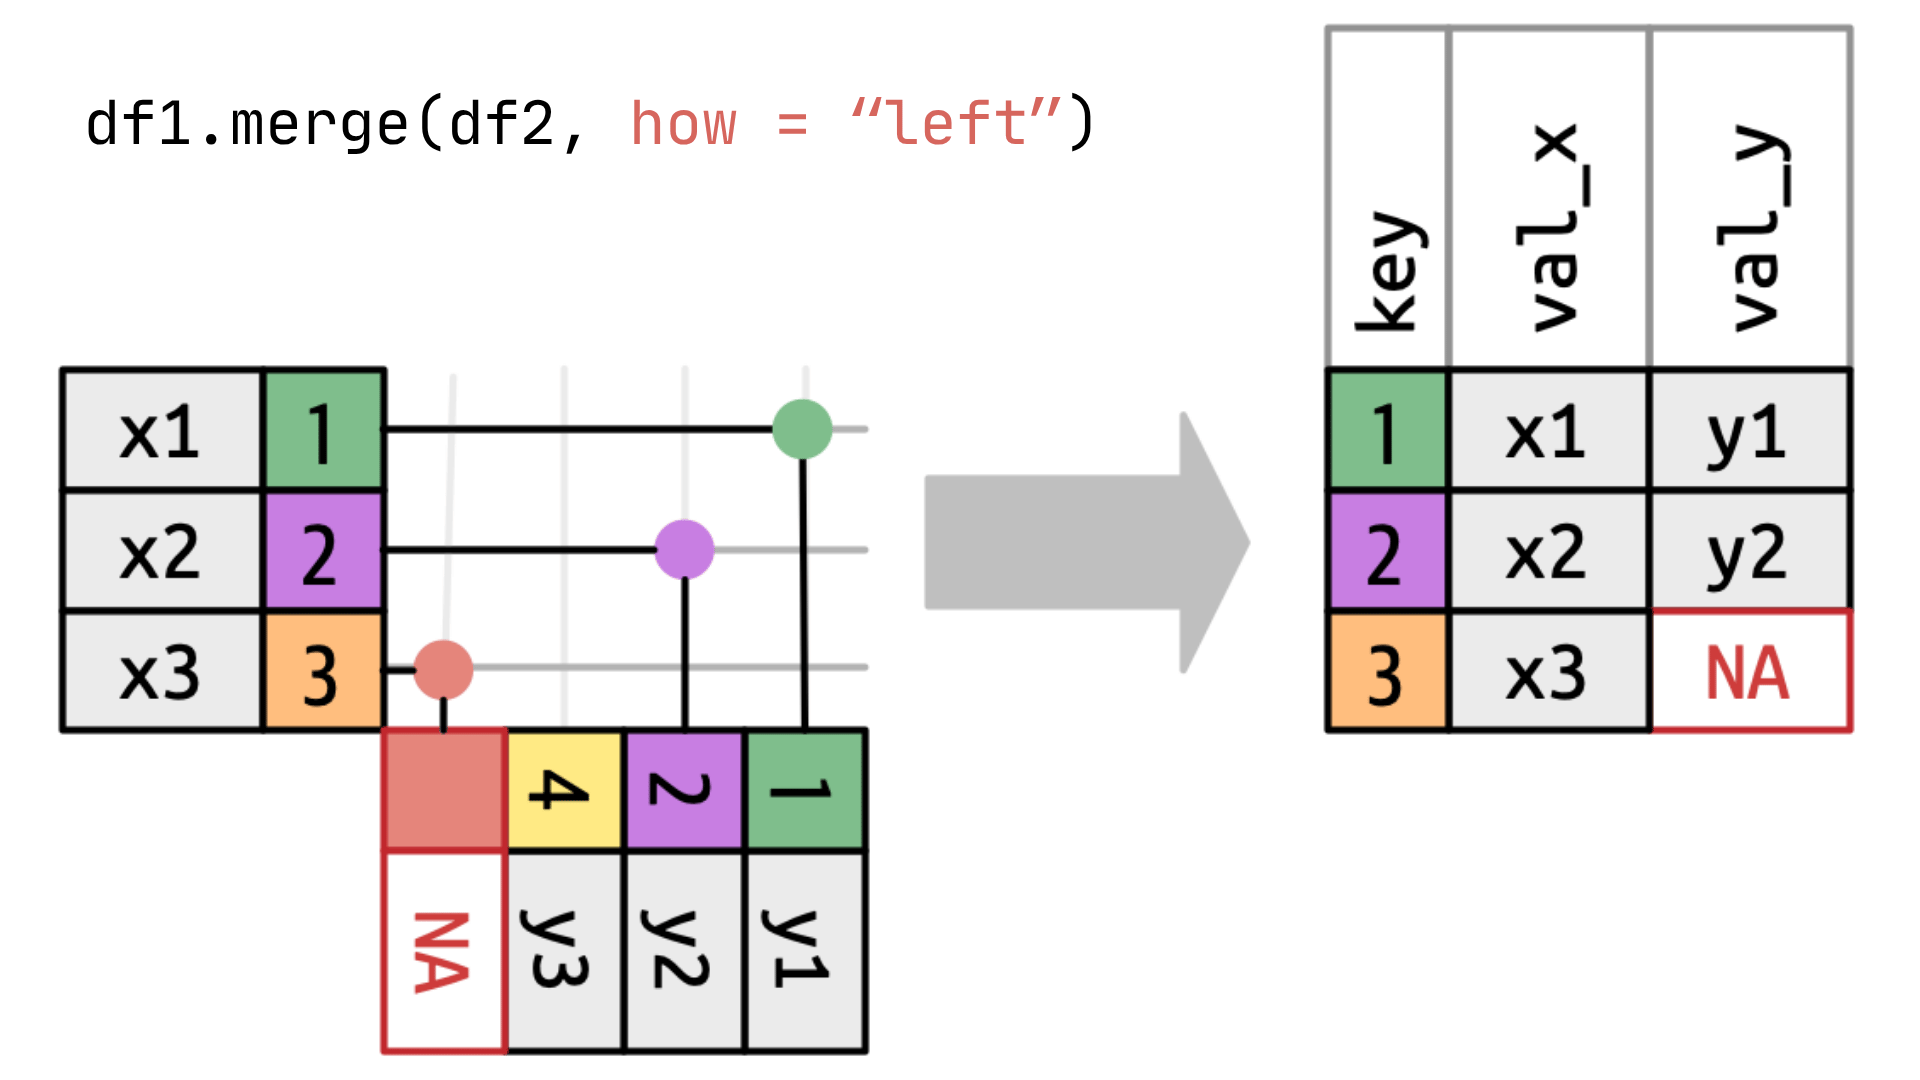
<figcaption aria-hidden="true">Illustration du <em>left join</em>. Source originale: <span class="citation" data-cites="wickham2023r">Wickham, Çetinkaya-Rundel, et Grolemund (2023)</span></figcaption>
</figure>


In [ ]:
left_merged = emissions.merge(
  filosofi,
  left_on = ["INSEE commune", "dep"],
  right_on = ["CODGEO", "dep"],
  how = "left"
)
left_merged.head(3)

Il est recommandé de toujours expliciter les clés de jointures par le biais des arguments `left_on`, `right_on` ou `on` si les noms de variables sont communs dans les deux bases.
Si on a des noms de variables communes entre les bases mais qu’elles ne sont pas définies comme clés de jointures, celles-ci ne seront pas utilisées pour joindre mais seront conservées avec un suffixe qui par défaut est `_x` et `_y` (paramétrable par le biais de l’argument `suffixes`).

La syntaxe `Pandas` étant directement inspirée de SQL, on a une traduction assez transparente de l’instruction ci-dessus en SQL:

``` sql
SELECT *
FROM emissions
LEFT JOIN filosofi
  ON emissions.`INSEE commune` = filosofi.CODGEO
  AND emissions.dep = filosofi.dep;
```

En faisant une jointure à gauche, on doit en principe avoir autant de lignes que la base de données à gauche:


In [ ]:
left_merged.shape[0] == emissions.shape[0]

True

Autrement, cela est signe qu’il y a une clé dupliquée à droite. Grâce à notre variable `id_right`, on peut savoir les codes communes à droite qui n’existent pas à gauche:


In [ ]:
left_merged.loc[left_merged['id_right'].isna()].tail(3)

Cela vient du fait que les deux jeux de données ne reposent pas sur la même version du code officiel géographique. Les données Filosofi, diffusées par l’API Melodi, reflètent le découpage communal le plus récent (2025), alors que les données d’émissions de l’Ademe, bien que mises à jour en 2025, n’ont pas encore répercuté certaines fusions de communes récentes. Par exemple, la commune de Courcouronnes est toujours présente telle quelle dans les données d’émissions (base de gauche):


In [ ]:
left_merged.loc[
  left_merged['id_right'].isna()
  & left_merged['Commune'].str.contains("COURCOURONNES", na=False)
]

Cette commune a pourtant fusionné avec Evry pour former la commune nouvelle d’Évry-Courcouronnes, seule forme sous laquelle elle apparaît désormais dans les données Filosofi (base de droite):


In [ ]:
filosofi.loc[
  filosofi['LIBGEO']
  .str.lower()
  .str.contains("courcouronnes", na=False)
]

Dans un exercice de construction de statistiques publiques, on ne pourrait donc se permettre cette disjonction des années.

## 4.2 *Right join*

Le principe est le même mais cette fois c’est la base de droite qui est prise sous forme de pivot:

<figure>
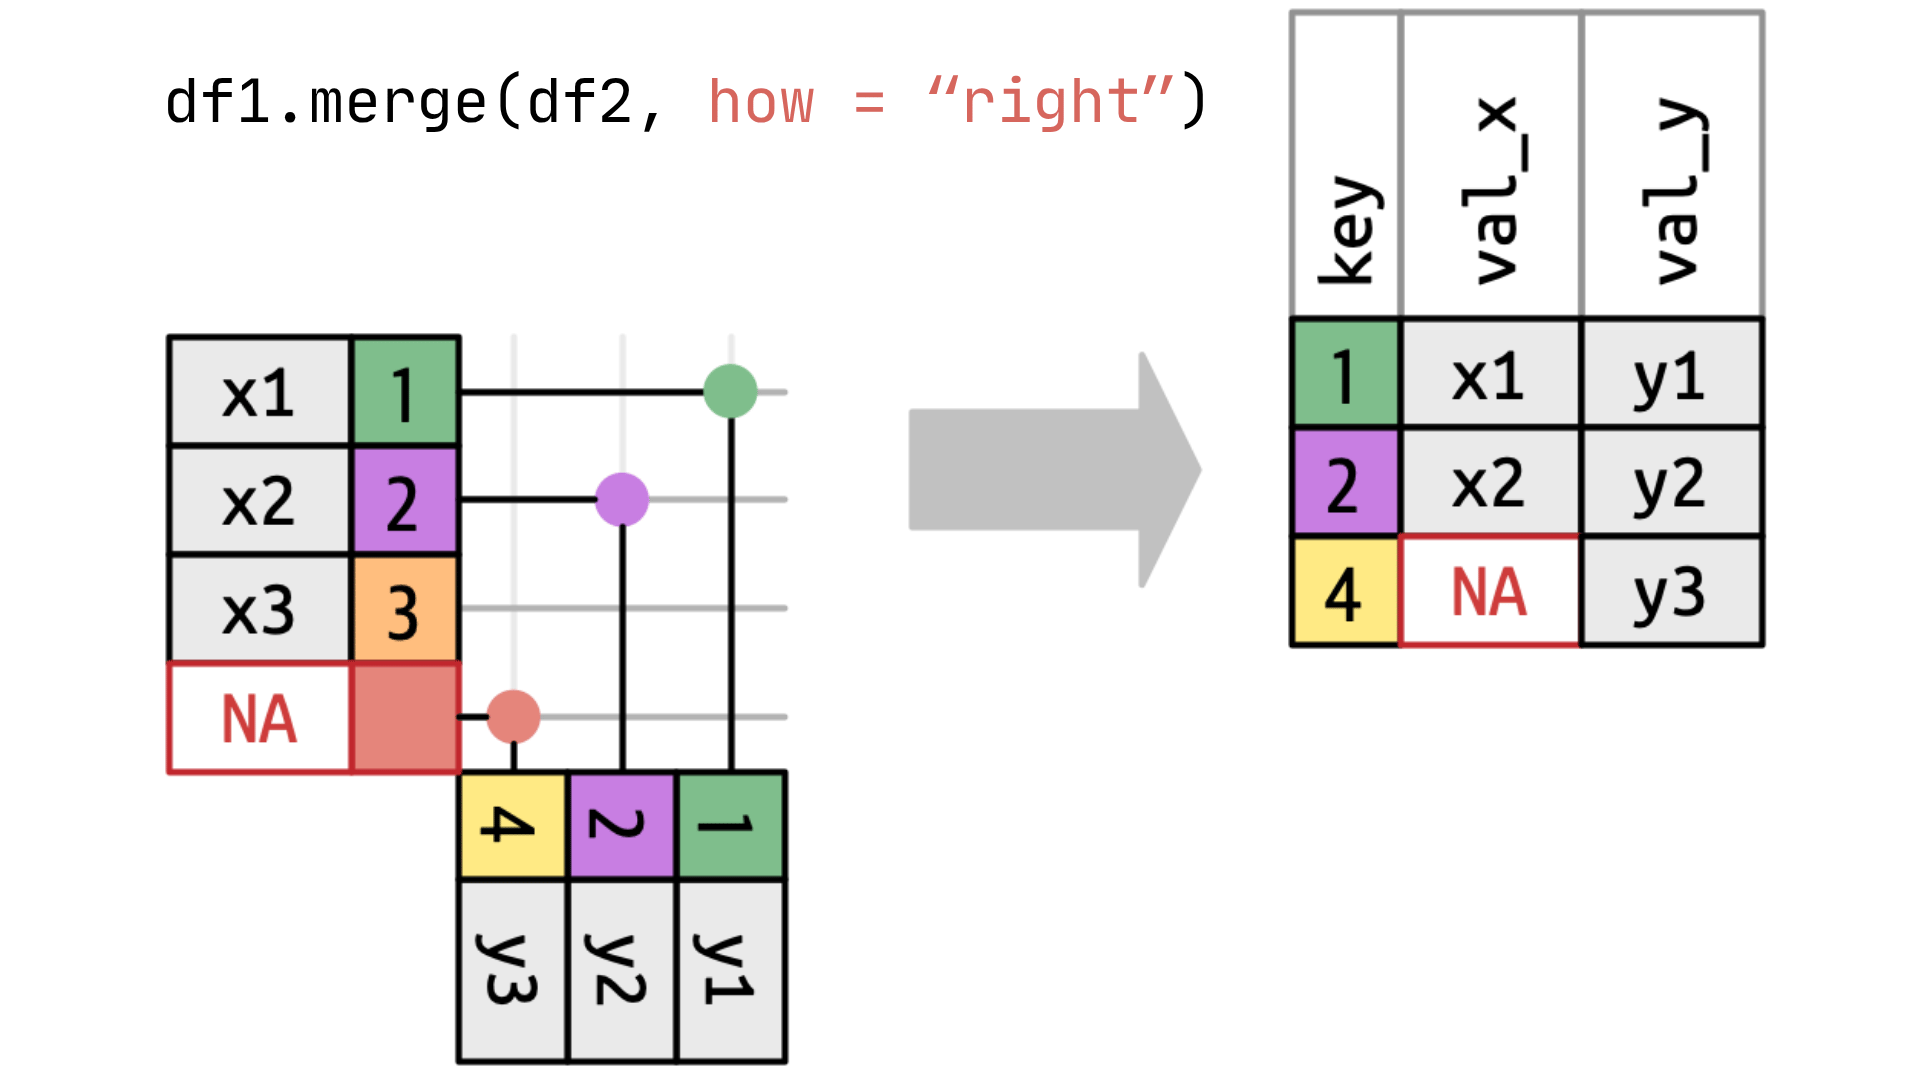
<figcaption aria-hidden="true">Illustration du <em>right join</em>. Source originale: <span class="citation" data-cites="wickham2023r">Wickham, Çetinkaya-Rundel, et Grolemund (2023)</span></figcaption>
</figure>


In [ ]:
right_merged = emissions.merge(
  filosofi,
  left_on = ["INSEE commune", "dep"],
  right_on = ["CODGEO", "dep"],
  how = "right"
)
right_merged.head(3)

L’instruction équivalente en SQL serait

``` sql
SELECT *
FROM filosofi
RIGHT JOIN emissions
  ON filosofi.CODGEO = emissions.`INSEE commune`
  AND filosofi.dep = emissions.dep;
```

On peut, comme précédemment, vérifier la cohérence des dimensions:


In [ ]:
right_merged.shape[0] == filosofi.shape[0]

True

Pour vérifier le nombre de lignes des données Filosofi que nous n’avons pas dans notre jeu d’émissions de gaz carbonique, on peut faire


In [ ]:
right_merged['id_left'].isna().sum()

np.int64(120)

C’est un nombre faible. Quelles sont ces observations ?


In [ ]:
right_merged.loc[
  right_merged['id_left'].isna(),
  filosofi.columns.tolist() + emissions.columns.tolist()
]

120 rows × 21 columns

Il est suprenant de voir que Paris, Lyon et Marseille sont présents
dans la base des statistiques communales mais pas dans celles des émissions.
Pour comprendre pourquoi, recherchons dans nos données d’émissions les observations liées à Marseille:


In [ ]:
emissions.loc[
  emissions["Commune"]
  .str.upper()
  .str.contains('MARSEILLE-')
]

Cela vient du fait que le jeu de données des émissions de l’Ademe propose de l’information sur les arrondissements dans les trois plus grandes villes
là où le jeu de données de l’Insee ne fait pas cette décomposition.

## 4.3 *Inner join*

Il s’agit du jeu de données où les clés sont retrouvées à l’intersection des deux tables.

<figure>
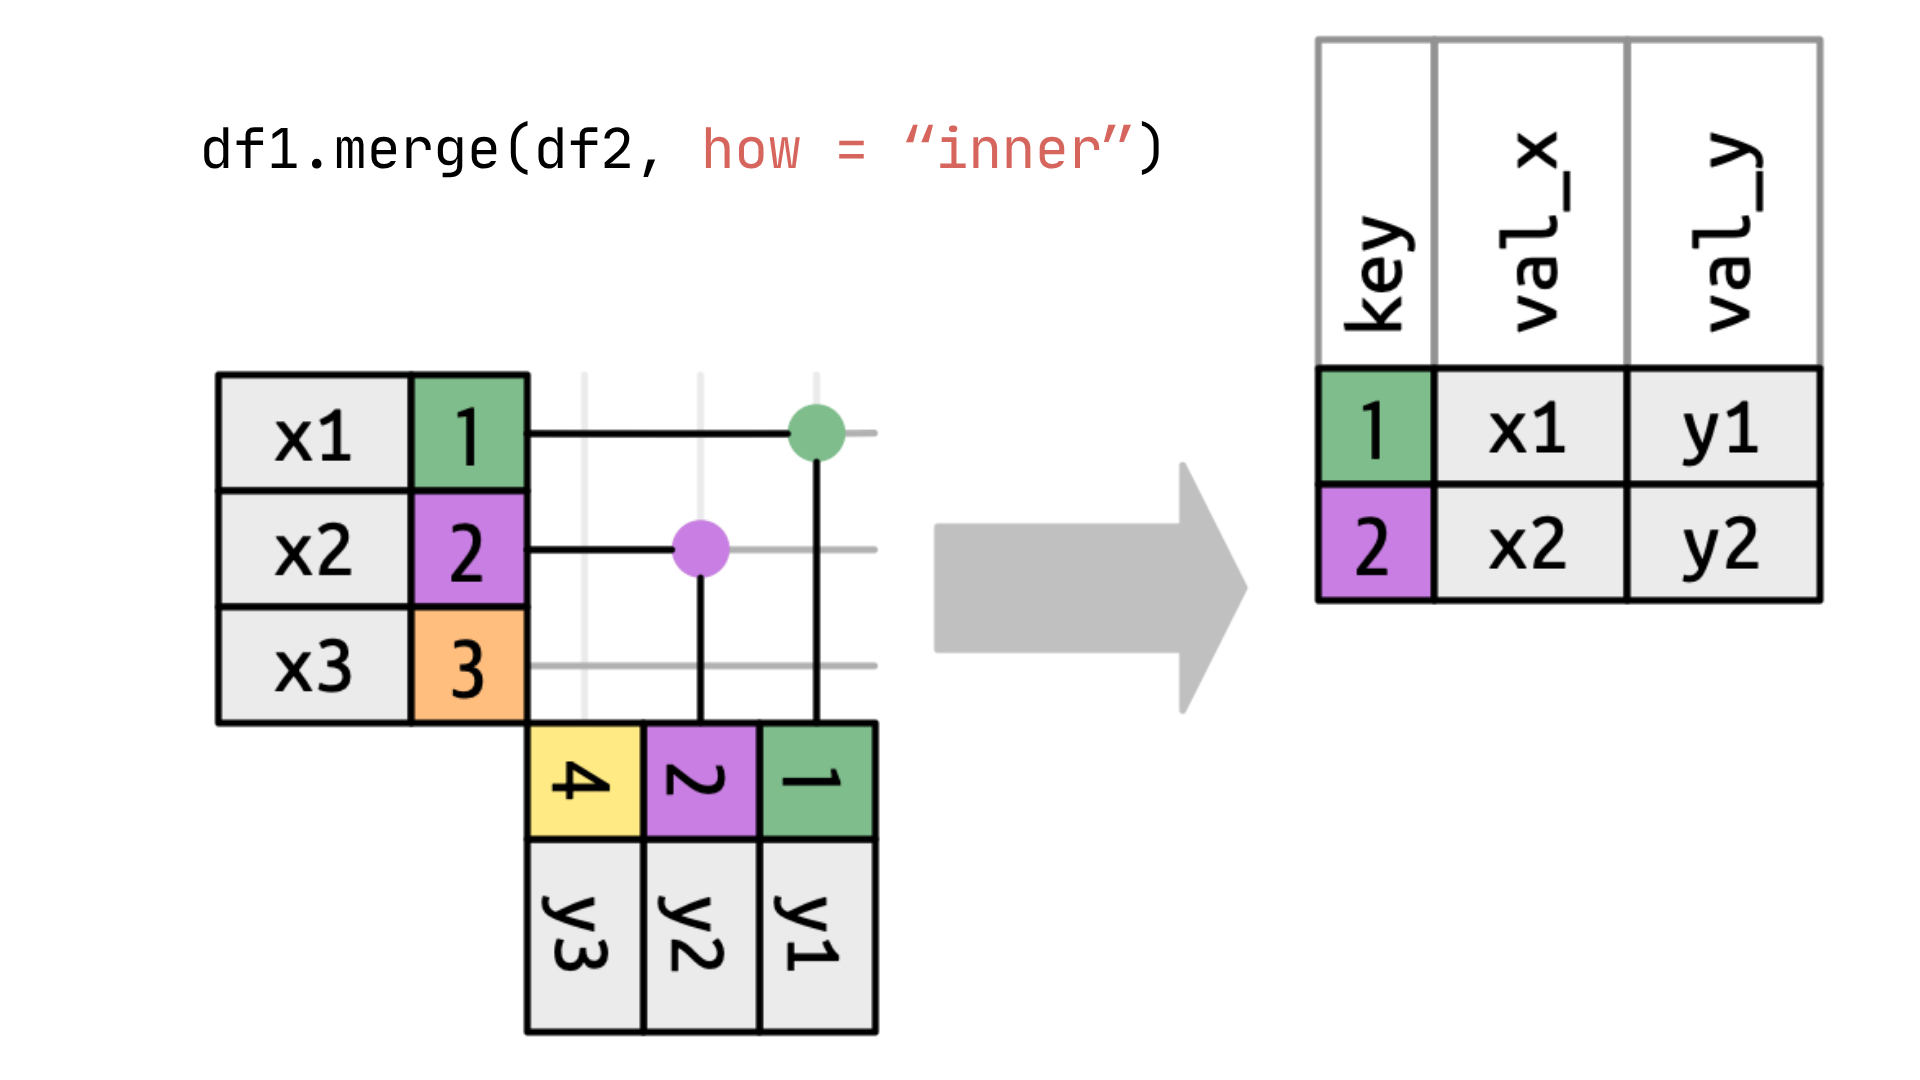
<figcaption aria-hidden="true">Illustration du <em>inner join</em>. Source originale: <span class="citation" data-cites="wickham2023r">Wickham, Çetinkaya-Rundel, et Grolemund (2023)</span></figcaption>
</figure>


In [ ]:
inner_merged = emissions.merge(
  filosofi,
  left_on = ["INSEE commune", "dep"],
  right_on = ["CODGEO", "dep"],
  how = "inner"
)
inner_merged.head(3)

En SQL, cela donne

``` sql
SELECT *
FROM emissions
INNER JOIN filosofi
  ON emissions.`INSEE commune` = filosofi.CODGEO
  AND emissions.dep = filosofi.dep;
```

Le nombre de lignes dans notre jeu de données peut être comparé au jeu de droite et de gauche:


In [ ]:
inner_merged.shape[0] == (
  left_merged.shape[0] - left_merged['id_right'].isna().sum()
)

np.True_

In [ ]:
inner_merged.shape[0] == (
  right_merged.shape[0] - right_merged['id_left'].isna().sum()
)

np.True_

## 4.4 *Full join*

Le *full join* est un pivot à gauche puis à droite pour les informations qui n’ont pas été trouvées

<figure>
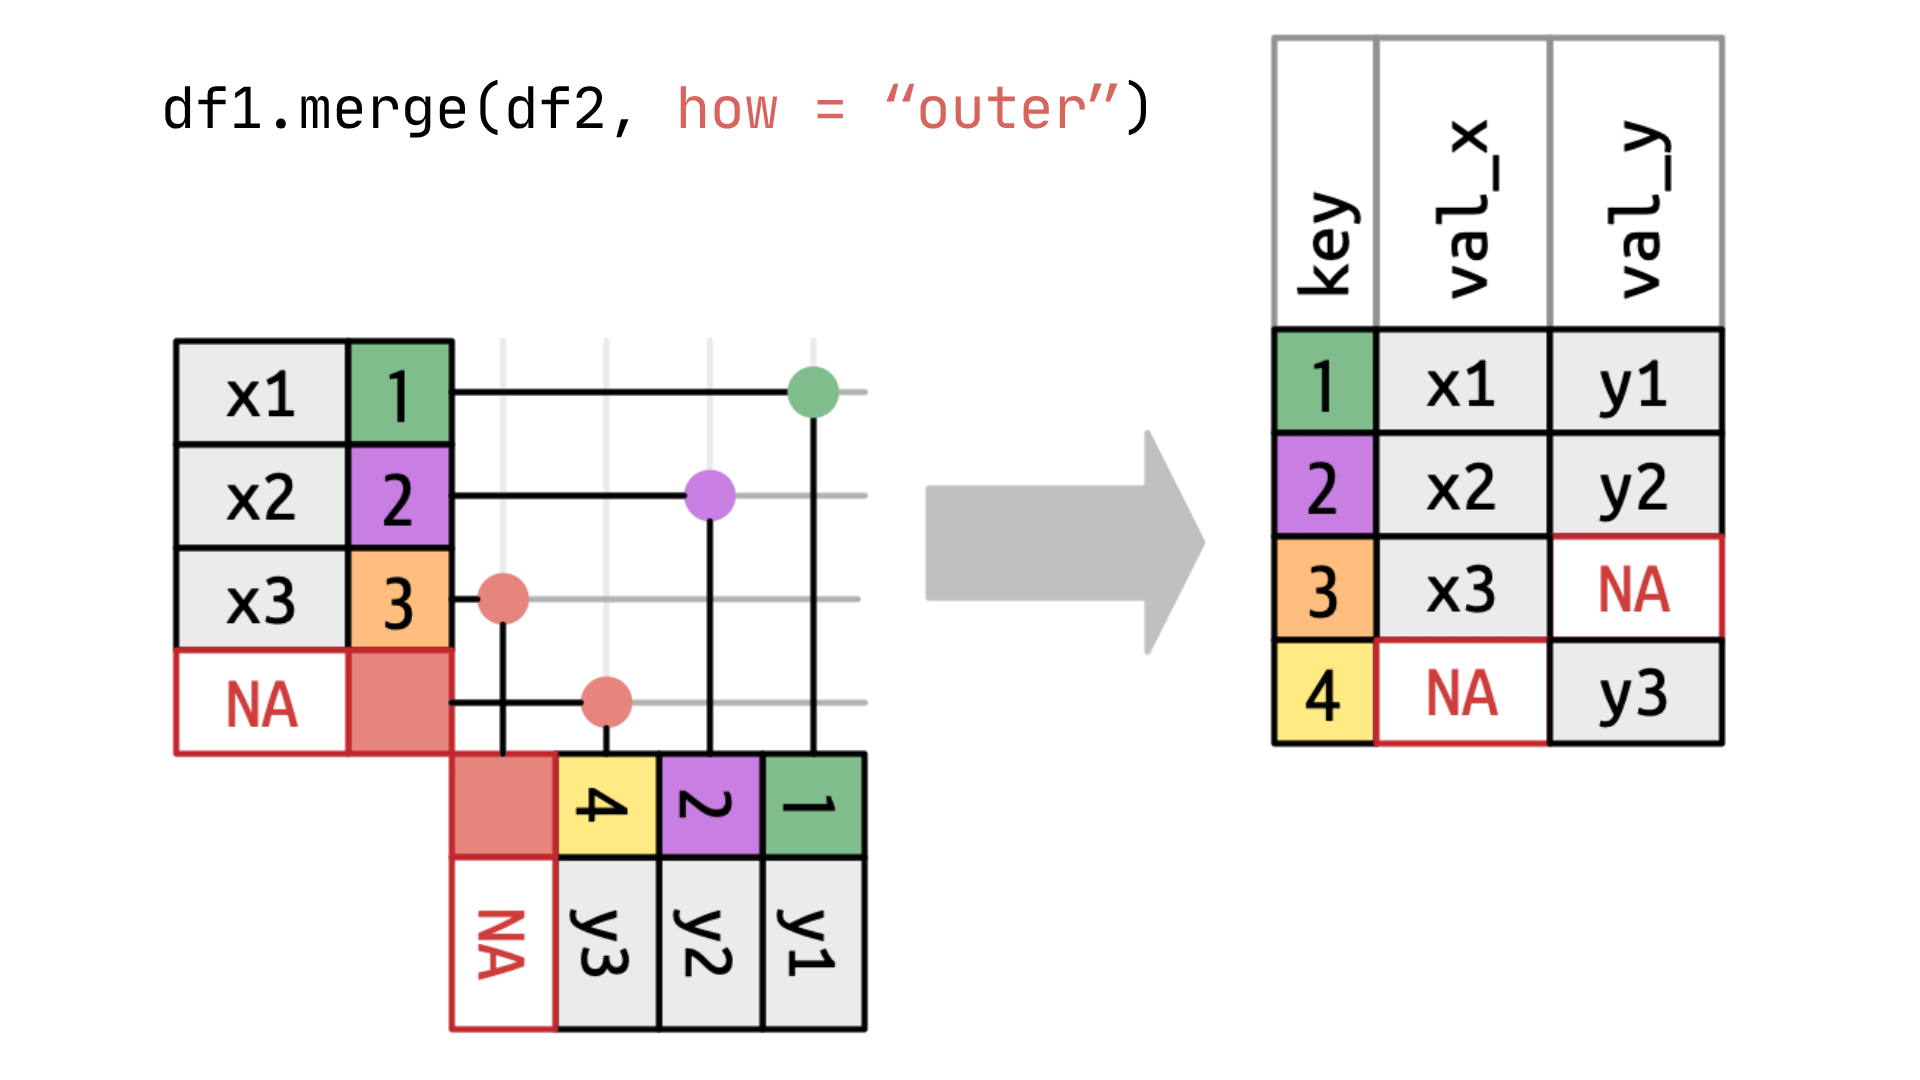
<figcaption aria-hidden="true">Illustration du <em>full outer join</em>. Source originale: <span class="citation" data-cites="wickham2023r">Wickham, Çetinkaya-Rundel, et Grolemund (2023)</span></figcaption>
</figure>


In [ ]:
full_merged = emissions.merge(
  filosofi,
  left_on = ["INSEE commune", "dep"],
  right_on = ["CODGEO", "dep"],
  how = "outer"
)
full_merged.head(3)

Comme d’habitude, la traduction en SQL est presque immédiate:

``` sql
SELECT *
FROM emissions
FULL OUTER JOIN filosofi
  ON emissions.`INSEE commune` = filosofi.CODGEO
  AND emissions.dep = filosofi.dep;
```

Cette fois, on a une combinaison de nos trois jeux de données initiaux:

-   Le *inner join* ;
-   Le *left join* sur les observations sans clé de droite ;
-   Le *right join* sur les observations sans clé de gauche ;


In [ ]:
(
  full_merged['id_left'].isna().sum() + full_merged['id_right'].isna().sum()
) == (
  left_merged['id_right'].isna().sum() + right_merged['id_left'].isna().sum()
)

np.True_

Les colonnes `id_left` et `id_right` n’avaient d’utilité que pour illustrer les jointures ci-dessus. On les retire de nos jeux de données avant de poursuivre, pour ne pas polluer les traitements ultérieurs :


In [ ]:
emissions = emissions.drop(columns = ['id_left'])
filosofi = filosofi.drop(columns = ['id_right'])

## 4.5 En résumé

Les quatre principaux types de jointures sont ainsi les suivantes:

<table>
<colgroup>
<col style="width: 50%" />
<col style="width: 50%" />
</colgroup>
<tbody>
<tr>
<td style="text-align: left;"><div width="50.0%" data-layout-align="left">
<figure>
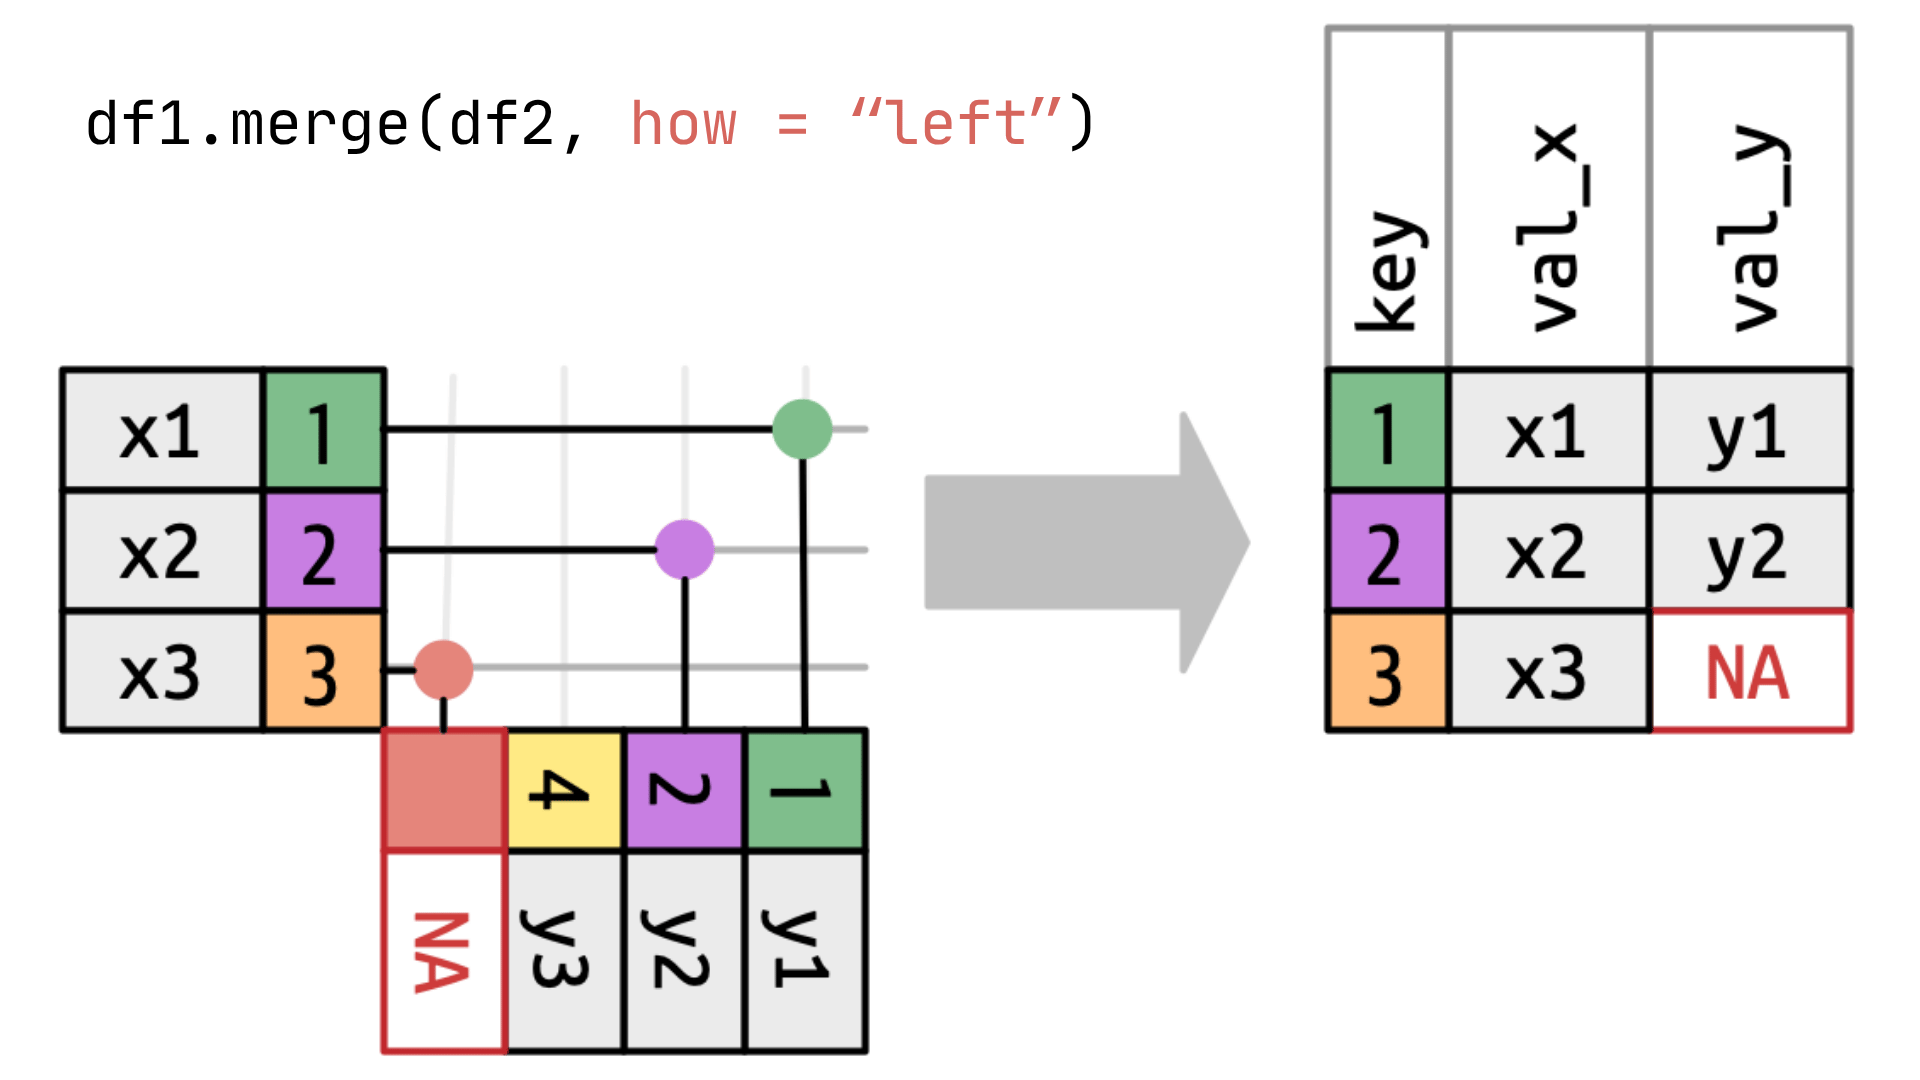
<figcaption aria-hidden="true"><em>Left join</em> (source: <span class="citation" data-cites="wickham2023r">Wickham, Çetinkaya-Rundel, et Grolemund (2023)</span>)</figcaption>
</figure>
</div></td>
<td style="text-align: left;"><div width="50.0%" data-layout-align="left">
<figure>
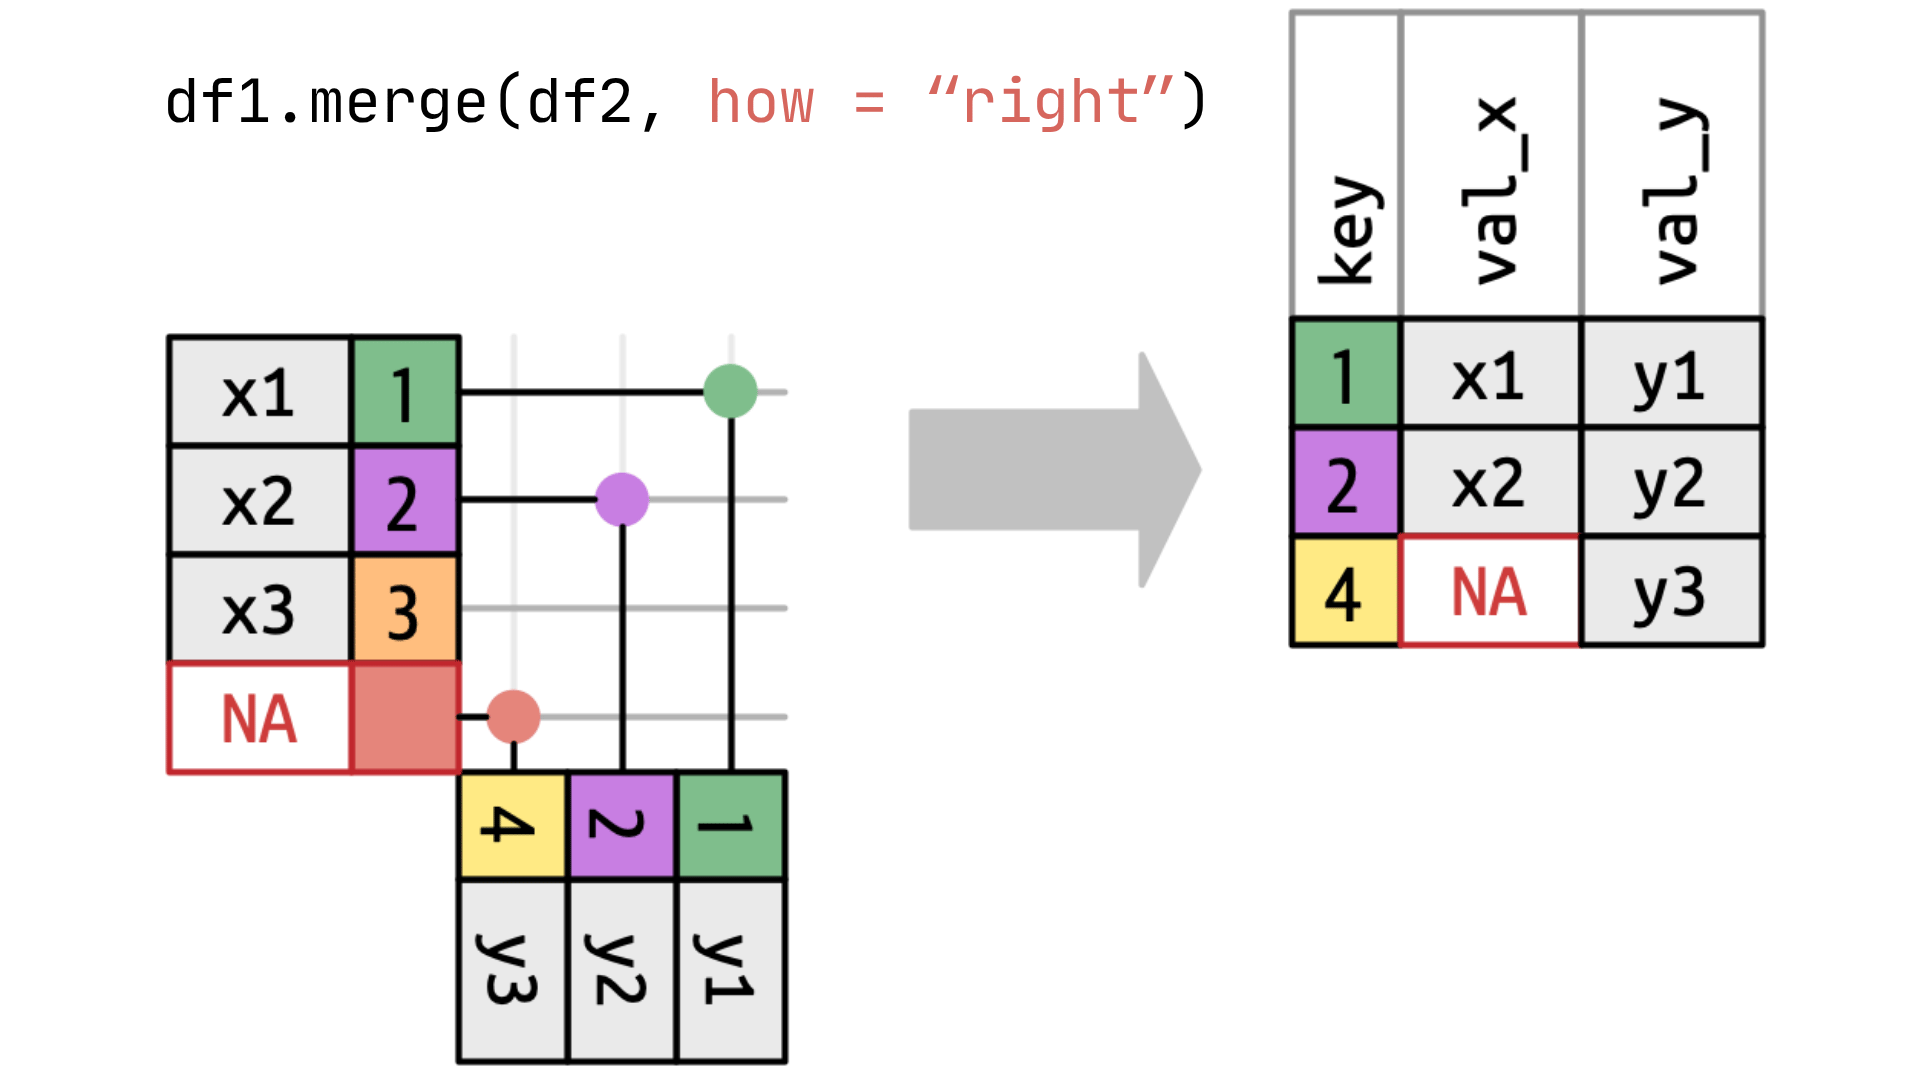
<figcaption aria-hidden="true"><em>Right join</em> (source: <span class="citation" data-cites="wickham2023r">Wickham, Çetinkaya-Rundel, et Grolemund (2023)</span>)</figcaption>
</figure>
</div></td>
</tr>
</tbody>
</table>

<table>
<colgroup>
<col style="width: 50%" />
<col style="width: 50%" />
</colgroup>
<tbody>
<tr>
<td style="text-align: left;"><div width="50.0%" data-layout-align="left">
<figure>
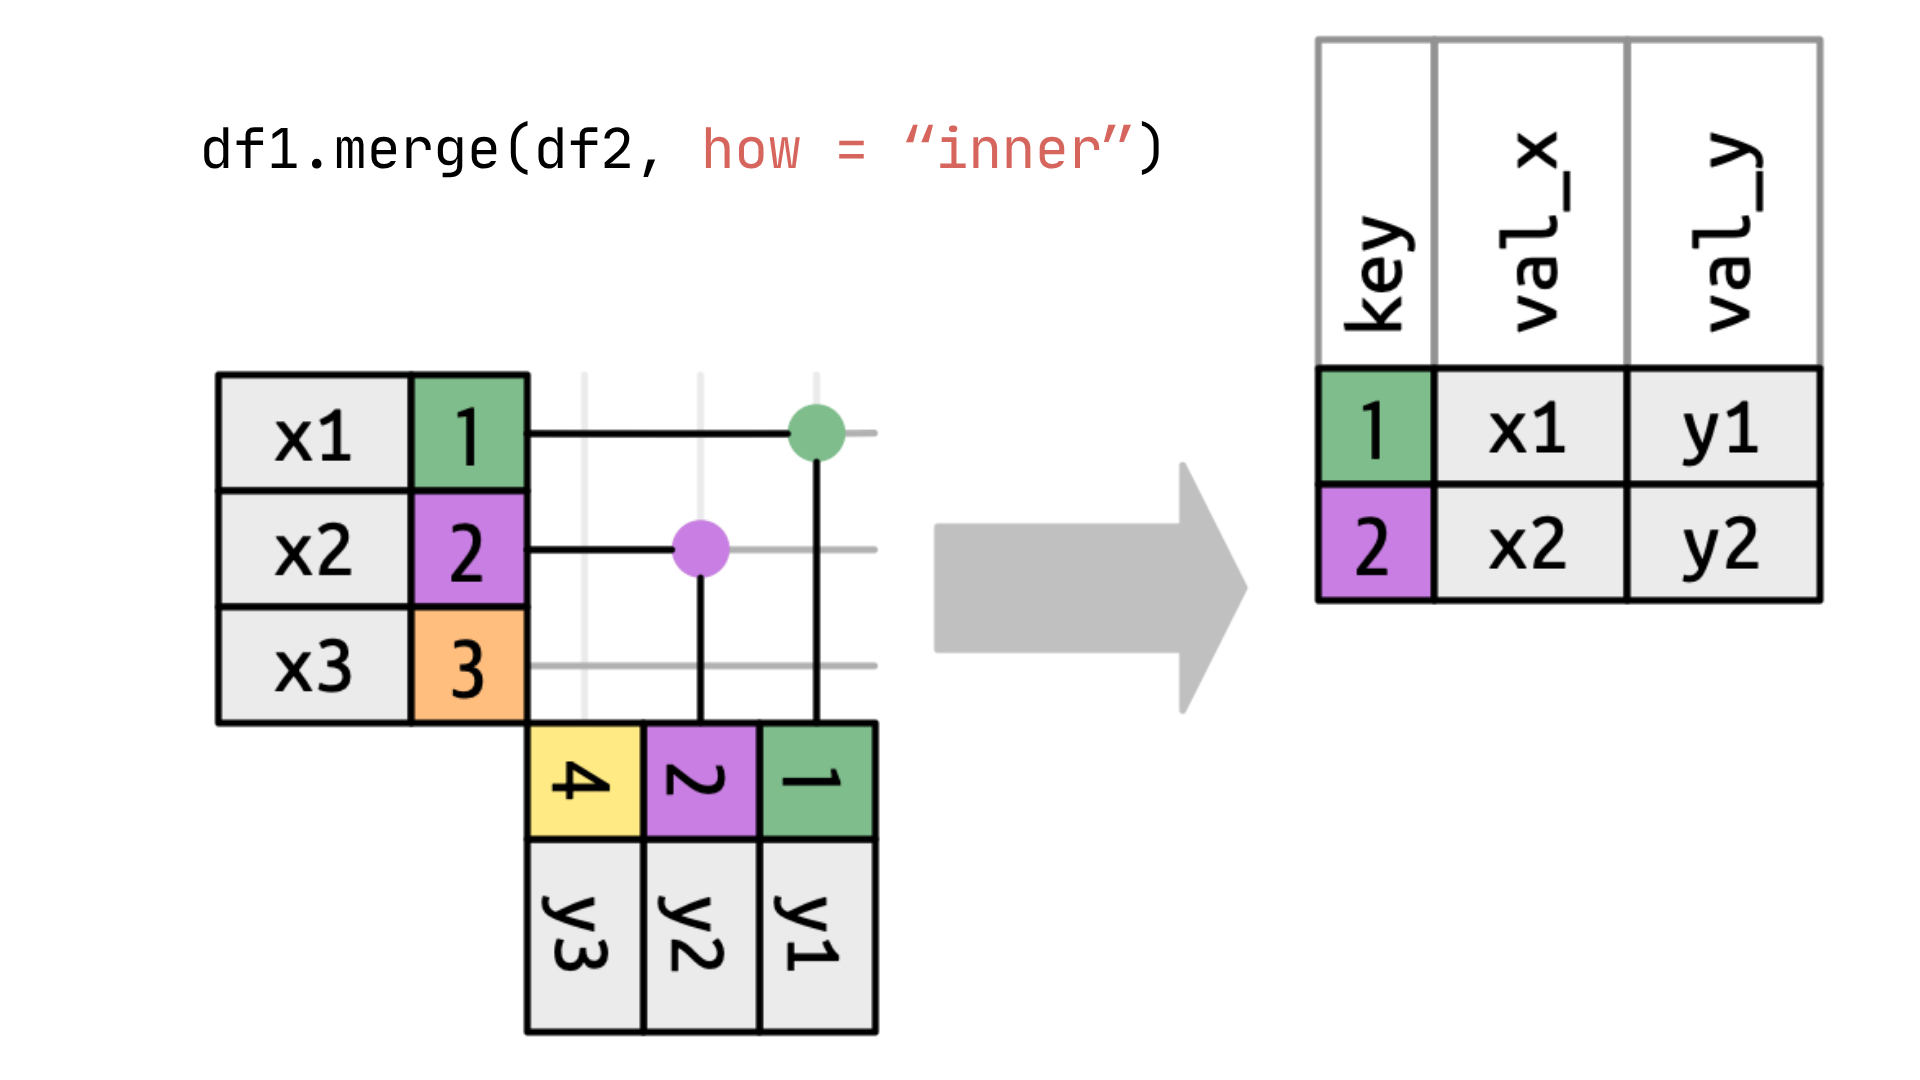
<figcaption aria-hidden="true"><em>Inner join</em> (source: <span class="citation" data-cites="wickham2023r">Wickham, Çetinkaya-Rundel, et Grolemund (2023)</span>)</figcaption>
</figure>
</div></td>
<td style="text-align: left;"><div width="50.0%" data-layout-align="left">
<figure>
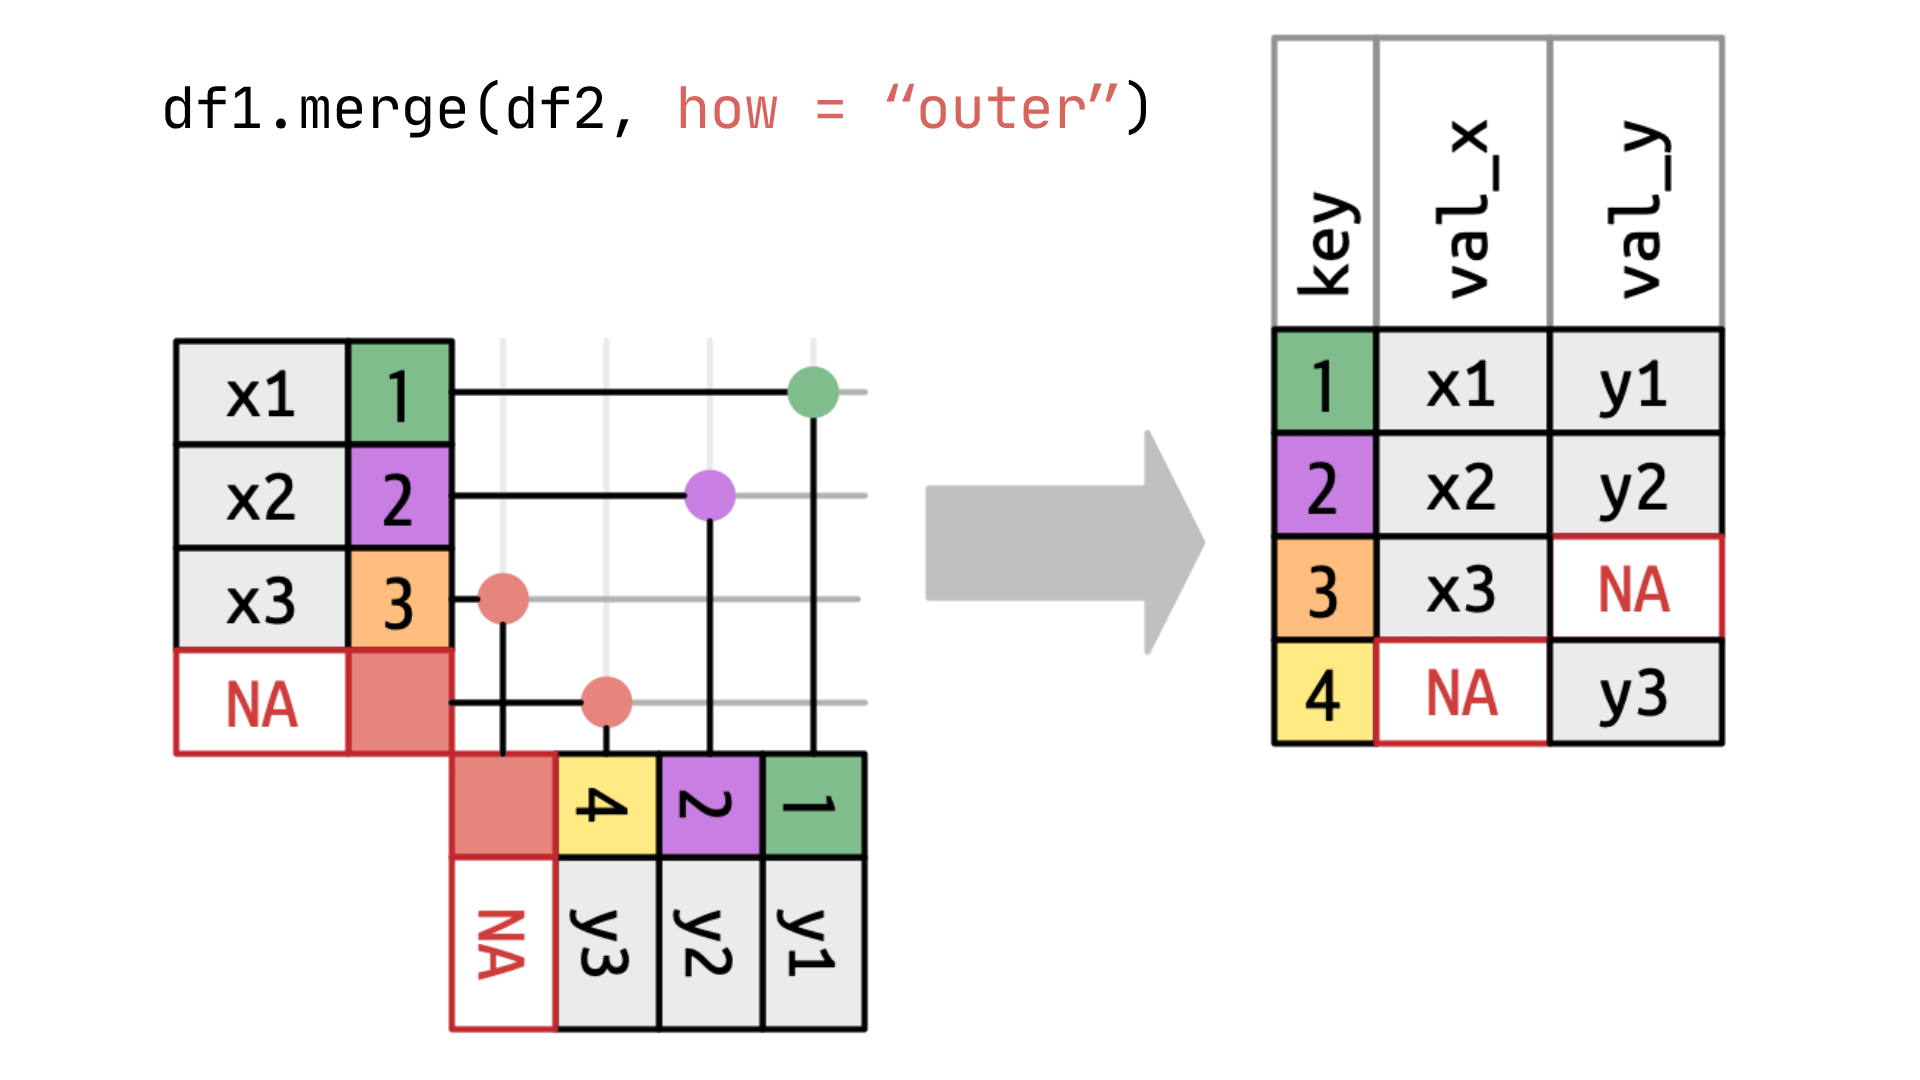
<figcaption aria-hidden="true"><em>Full outer join</em> (source: <span class="citation" data-cites="wickham2023r">Wickham, Çetinkaya-Rundel, et Grolemund (2023)</span>)</figcaption>
</figure>
</div></td>
</tr>
</tbody>
</table>

<table>
<colgroup>
<col style="width: 50%" />
<col style="width: 50%" />
</colgroup>
<tbody>
<tr>
<td style="text-align: left;"><div width="50.0%" data-layout-align="left">
<p>Les principales méthodes de fusion de données</p>
</div></td>
<td style="text-align: left;"><div width="50.0%" data-layout-align="left">
&#10;</div></td>
</tr>
</tbody>
</table>

Figure 4.1

Dans une version comique, cela donne:

![](https://external-preview.redd.it/yOLzCR0qSzul2WpjQorxINB0xpU3_N9twmFVsgbGJwQ.jpg?auto=webp&s=4feedc91302ba635b3028a21b98d047def5cdc2b)

Il existe bien-sûr d’autres types de jointures, basées sur la négation: *semi-join*, *anti-join*, etc. Ces méthodes sont moins fréquemment utilisées mais sont utiles lorsqu’on cherche à déterminer la discordance entre deux jeux de données.

# 5. Exemples d’identifiants dans les données françaises

Nous avons mis en avant l’intérêt de disposer d’identifiants communs à des bases de données plutôt que se fier à des informations textuelles bruitées. Nous allons maintenant évoquer trois identifiants importants pour les utilisateurs de données françaises:

-   Le code officiel géographique, identifiant unique pour des données géographiques
-   Le NIR, ou numéro de sécurité sociale, identifiant individuel français
-   Le code SIRENE, identifiant unique pour les entreprises ayant une activité en France.

## 5.1 Le Code officiel géographique (COG): l’identifiant des données géographiques

Pour les données géographiques, il existe de nombreux identifiants selon la problématique d’étude.

Parmi les besoins principaux, on retrouve le fait d’apparier des données géographiques à partir d’un identifiant administratif commun. Par exemple, associer deux jeux de données au niveau communal.

Pour cela, l’identifiant de référence est le code Insee, issu du [Code officiel géographique (COG)](https://www.insee.fr/fr/information/2560452) que nous utilisons depuis le dernier chapitre et que nous aurons amplement l’occasion d’exploiter au cours des différents chapitres de ce cours.

La géographie administrative étant en évolution perpétuelle, la base des code Insee est une base vivante. Le site et les API de l’Insee permettent de récupérer l’historique d’après-guerre afin de pouvoir faire de l’analyse géographique sur longue période.

Les codes postaux ne peuvent être considérés comme un identifiant : ils peuvent regrouper plusieurs communes ou, au contraire, une même commune peut avoir plusieurs codes postaux. Il s’agit d’un système de gestion de la Poste qui n’a pas été construit pour l’analyse statistique.

Pour se convaincre du problème, à partir des données mises à disposition par La Poste, on peut voir que le code postal 11420 correspond à 11 communes:


In [ ]:
codes_postaux = pd.read_csv(
  "https://datanova.laposte.fr/data-fair/api/v1/datasets/laposte-hexasmal/raw",
  sep = ";", encoding = "latin1",
  dtype = {"Code_postal": "str", "#Code_commune_INSEE": "str"}
)
codes_postaux.loc[codes_postaux['Code_postal'] == "11420"]

En anticipant sur les compétences développées lors des prochains chapitres, nous pouvons représenter le problème sous forme cartographique en prenant l’exemple de l’Aude. Le code pour produire la carte des codes communes est donné tel quel, il n’est pas développé car il fait appel à des concepts et librairies qui seront présentés lors du prochain chapitre:


In [ ]:
!pip install cartiflette --quiet

In [ ]:
from cartiflette import carti_download

shp_communes = carti_download(
  values = ["11"],
  crs = 4326,
  borders = "COMMUNE",
  simplification=50,
  filter_by="DEPARTEMENT",
  source="EXPRESS-COG-CARTO-TERRITOIRE",
  year=2022)

codes_postaux11 = shp_communes.merge(
  codes_postaux,
  left_on = "INSEE_COM",
  right_on = "#Code_commune_INSEE"
)
codes_postaux11 = codes_postaux11.dissolve(by = "Code_postal")

This is an experimental version of cartiflette published on PyPi.
To use the latest stable version, you can install it directly from GitHub with the following command:
pip install git+https://github.com/inseeFrLab/cartiflette.git

In [ ]:
# Carte
ax = shp_communes.plot(color='white', edgecolor='blue', linewidth = 0.5)
ax = codes_postaux11.plot(ax = ax, color='none', edgecolor='black')
ax.set_axis_off()

## 5.2 Sirene: l’identifiant dans les données d’entreprises

Pour relier les microdonnées d’entreprises françaises, il existe un numéro unique d’identification : le [numéro `Siren`](https://entreprendre.service-public.fr/vosdroits/F32135). Il s’agit d’un numéro d’identification dans un répertoire légal d’entreprise indispensable pour toutes démarches juridiques, fiscales…

Pour les entreprises qui possèdent plusieurs établissements - par exemple dans plusieurs villes - il existe un identifiant dérivé qui s’appelle le [`Siret`](https://www.economie.gouv.fr/cedef/numero-siret): aux 9 chiffres du numéro Sirene s’ajoutent 5 chiffres d’identifications de l’établissement. D’ailleurs, les administrations publiques sont également concernées par le numéro Siren: étant amenées à effectuer des opérations de marchés (achat de matériel, locations de biens, etc.) elles disposent également d’un identifiant Siren.

Etant inscrits dans des répertoires légaux pour lesquels les citoyens sont publics, les numéros Siren et les noms des entreprises associées sont disponibles en *open data*, par exemple sur [annuaire-entreprises.data.gouv.fr/](https://annuaire-entreprises.data.gouv.fr/) pour une recherche ponctuelle, sur [data.gouv.fr](https://www.data.gouv.fr/fr/datasets/base-sirene-des-entreprises-et-de-leurs-etablissements-siren-siret/).

Cette base Sirene est une mine d’information, parfois comique, sur les entreprises françaises. Par exemple, le site [tif.hair/](https://tif.hair/) s’est amusé à répertorier la part des salons de coiffures proposant des jeux de mots dans le nom du salon.

Lorsqu’un entrepreneur déclare la création d’une entreprise, il reçoit un numéro Sirene et un code d’activité (le [code APE](https://entreprendre.service-public.fr/vosdroits/F33050)) relié à la description qu’il a déclaré de l’activité de son entreprise. Ce code permet de classer l’activité d’une entreprise dans la [Nomenclature d’activités françaises (NAF)](https://www.insee.fr/fr/information/2406147) ce qui servira à l’Insee pour la publication de statistiques sectorielles. En l’occurrence, pour les coiffeurs, le code dans la NAF est [`96.02A`](https://www.insee.fr/fr/metadonnees/nafr2/sousClasse/96.02A?champRecherche=false).

Il est possible à partir de la base disponible en *open data* d’avoir en quelques lignes de `Python` la liste de tous les coiffeurs puis de s’amuser à explorer ces données (objet du prochain exercice optionnel).

L’exercice suivant, optionnel, propose de s’amuser à reproduire de manière simplifiée le recensement fait par [tif.hair/](https://tif.hair/) des jeux de mots dans les salons de coiffure. Il permet de pratiquer quelques méthodes de manipulation textuelle, en avance de phase sur le chapitre consacré aux [expressions régulières](../../content/manipulation/04b_regex_TP.qmd).

Le jeu de données de l’ensemble des entreprises étant assez volumineux (autour de 4Go en CSV après décompression), il est plus pratique de partir sur un jeu de données au format `Parquet`, plus optimisé (plus de détails sur ce format dans le [chapitre d’approfondissement](../../content/modern-ds/05_parquet_s3.qmd) qui lui est consacré).

Pour lire ce type de fichiers de manière optimale, il est conseillé d’utiliser la librairie `DuckDB` qui permet de ne consommer que les données nécessaires et non de télécharger l’ensemble du fichier pour n’en lire qu’une partie comme ce serait le cas avec `Pandas` (voir le [dernier chapitre](../../content/manipulation/02_pandas_beyond.qmd) de cette partie, section “Aller au-delà de `Pandas`”). La requête SQL suivante se traduit en langage naturel par l’instruction suivante: *“A partir du fichier `Parquet`, je ne veux que quelques colonnes du fichier pour les coiffeurs (APE: 96.02A) dont le nom de l’entreprise (`denominationUsuelleEtablissement`) est renseigné”*:


In [ ]:
import duckdb
coiffeurs = duckdb.sql("""
  SELECT
    siren, siret, dateDebut, enseigne1Etablissement, activitePrincipaleEtablissement, denominationUsuelleEtablissement
  FROM
    read_parquet('https://minio.lab.sspcloud.fr/lgaliana/data/sirene2024.parquet')
  WHERE
    activitePrincipaleEtablissement == '96.02A'
    AND
    denominationUsuelleEtablissement IS NOT NULL
""")
coiffeurs = coiffeurs.df()

In [ ]:
coiffeurs.head(3)


<div class="callout callout-style-default callout-tip callout-titled">
<div class="callout-header d-flex align-content-center">
<div class="callout-icon-container">
<i class="callout-icon"></i>
</div>
<div class="callout-title-container flex-fill">
Exercice optionnel : les coiffeurs blagueurs
</div>
</div>
<div class="callout-body-container callout-body">

Dans cet exercice, nous allons considérer exclusivement la variable `denominationUsuelleEtablissement`.

1.  Dans cette base, `[ND]` est un code pour valeur manquante. Comme `Python` n’a pas de raison de le savoir *a priori* et donc d’avoir interprété ces valeurs comme étant manquantes, utiliser la méthode `replace` pour remplacer `[ND]` par un champ textuel vide. Recoder également les valeurs manquantes sous forme de champ textuel vide afin d’éviter des erreurs ultérieures liées à l’impossibilité d’appliquer certaines méthodes textuelles aux valeurs manquantes.
2.  Rechercher toutes les observations où le terme `tif` apparaît en faisant attention à la capitalisation de la variable. Regarder quelques observations
3.  A partir de [cet exemple](https://stackoverflow.com/a/23996414/9197726), normaliser les noms des salons en retirant les caractères spéciaux et compter les jeux de mots les plus fréquents

</div>
</div>

Avec la question 2, on retrouve une liste de jeux de mots assez imaginatifs à partir du terme `tif`:


Voici sous une forme plus interactive l’ensemble des coiffeurs qui possèdent les termes `tif` dans le nom de leur entreprise déposée dans les données officielles:

Bien sûr, pour aller plus loin, il faudrait mieux normaliser les données, vérifier que l’information recherchée n’est pas à cheval sur plusieurs colonnes et bien sûr faire de l’inspection visuelle pour détecter les jeux de mots cachés. Mais déjà, en quelques minutes, on a des statistiques partielles sur le phénomène des coiffeurs blagueurs.

### 5.2.1 Le NIR et la question de la confidentialité des identifiants individuels

En ce qui concerne les individus, il existe un identifiant unique permettant de relier ceux-ci dans différentes sources de données : le [NIR](https://www.cnil.fr/fr/definition/nir-numero-dinscription-au-repertoire), aussi connu sous le nom de numéro Insee ou numéro de sécurité sociale.
Ce numéro est nécessaire à l’administration pour la gestion des droits à prestations sociales (maladie, vieillesse, famille…). Au-delà de cette fonction qui peut être utile au quotidien, ce numéro est un identifiant individuel unique dans le [Répertoire national d’identification des personnes physiques (RNIPP)](https://www.insee.fr/fr/metadonnees/definition/c1602).

Cet identifiant est principalement présent dans des bases de gestion, liées aux fiches de paie, aux prestations sociales, etc. Cependant, *a contrario* du numéro Sirene, celui-ci contient en lui-même plusieurs informations sensibles (<a href="#fig-nir-compo" class="quarto-xref">Figure 5.1</a>) - en plus d’être intrinsèquement relié à la problématique sensible des droits à la sécurité sociale.

<figure id="fig-nir-compo">
<img src="https://www.ameli.fr/sites/default/files/styles/webp_ckeditor/public/thumbnails/image/infographie_assures-regle-identification-assures.gif.webp?itok=j2owVDrB" />
<figcaption>Figure 5.1: Le numéro de sécurité sociale (Source: <a href="https://www.ameli.fr/assure/droits-demarches/principes/numero-securite-sociale">Améli</a>)</figcaption>
</figure>

Pour pallier ce problème, a récémment été mis en oeuvre le [code statistique non signifiant (CSNS)](https://www.insee.fr/fr/information/7635825?sommaire=7635842) ou NIR haché, un identifiant individuel anonyme non identifiant. L’objectif de cet identifiant anonymisé est de réduire la dissémination d’une information personnelle qui permettait certes aux fonctionnaires et chercheurs de relier de manière déterministe de nombreuses bases de données mais donnait une information non indispensable aux analystes sur les personnes en question. Bénichou, Espinasse, et Gilles (2023) décrivent plus en détail la manière dont les organisations de la statistique publique française peuvent utiliser ce code unique non signifiant pour associer entre elles diverses sources de données.

# 6. Exercices d’application

## 6.1 Pourquoi a-t-on besoin d’un code commune quand on a déjà son nom ?

Cet exercice va revenir un peu en arrière afin de saisir pourquoi nous avons pris comme hypothèse ci-dessus que le code commune était la clé de jointure.

> **Astuce 6.1**
>
> <div class="callout callout-style-default callout-tip callout-titled" id="tip-cle-jointure">
> <div class="callout-header d-flex align-content-center">
> <div class="callout-icon-container">
> <i class="callout-icon"></i>
> </div>
> <div class="callout-title-container flex-fill">
> Vérification des clés de jointure
> </div>
> </div>
> <div class="callout-body-container callout-body">
>
> On commence par vérifier les dimensions des `DataFrames` et la structure de certaines variables clés.
> En l’occurrence, les variables fondamentales pour lier nos données sont les variables communales.
> Ici, on a deux variables géographiques: un code commune et un nom de commune.
>
> 1.  Vérifier les dimensions des *DataFrames*.
>
> 2.  Identifier dans `filosofi` les noms de communes qui correspondent à plusieurs codes communes et sélectionner leurs codes. En d’autres termes, identifier les `LIBGEO` tels qu’il existe des doublons de `CODGEO` et les stocker dans un vecteur `x` (conseil: faire attention à l’index de `x`).
>
> On se focalise temporairement sur les observations où le libellé comporte plus de deux codes communes différents
>
> -   *Question 3*. Regarder dans `filosofi` ces observations.
>
> -   *Question 4*. Pour mieux y voir, réordonner la base obtenue par order alphabétique.
>
> -   *Question 5*. Déterminer la taille moyenne (variable nombre de personnes: `POPULATION`) et quelques statistiques descriptives de ces données.
>     Comparer aux mêmes statistiques sur les données où libellés et codes communes coïncident.
>
> -   *Question 6*. Vérifier les grandes villes (plus de 100 000 personnes),
>     la proportion de villes pour lesquelles un même nom est associé à différents codes commune.
>
> -   *Question 7*. Vérifier dans `filosofi` les villes dont le libellé est égal à Montreuil.
>     Vérifier également celles qui contiennent le terme *‘Saint-Denis’*.
>
> </div>
> </div>

Ce petit exercice permet donc de se rassurer car les libellés dupliqués
sont en fait des noms de commune identiques mais qui ne sont pas dans le même département.
Il ne s’agit donc pas d’observations dupliquées.
On peut donc se fier aux codes communes, qui eux sont uniques.

## 6.2 Calculer une empreinte carbone grâce à l’association entre des sources

> **Astuce 6.2**
>
> <div class="callout callout-style-default callout-tip callout-titled" id="tip-empreinte-carbone">
> <div class="callout-header d-flex align-content-center">
> <div class="callout-icon-container">
> <i class="callout-icon"></i>
> </div>
> <div class="callout-title-container flex-fill">
> Calculer l’empreinte carbone par habitant
> </div>
> </div>
> <div class="callout-body-container callout-body">
>
> En premier lieu, on va calculer l’empreinte carbone de chaque commune.
>
> 1.  Créer une variable `emissions` qui correspond aux émissions totales d’une commune
>
> 2.  Faire une jointure à gauche entre les données d’émissions et les données de cadrage\[^notebiais\].
>
> 3.  Calculer l’empreinte carbone (émissions totales / population).
>
> A ce stade nous pourrions avoir envie d’aller vers la modélisation pour essayer d’expliquer
> les déterminants de l’empreinte carbone à partir de variables communales.
> Une approche inférentielle nécessite néanmoins pour être pertinente de
> vérifier en amont des statistiques descriptives.
>
> 1.  Sortir un histogramme en niveau puis en log de l’empreinte carbone communale.
>
> 2.  Regarder la corrélation entre les variables de cadrage et l’empreinte carbone. Certaines variables semblent-elles pouvoir potentiellement influer sur l’empreinte carbone ?
>
> </div>
> </div>

A l’issue de la question 5, le graphique des corrélations est le suivant :


Avec une meilleure compréhension de nos données, obtenue grâce à cette association de sources, nous nous rapprochons de la statistique inférentielle. Dans le [prochain chapitre](../../content/manipulation/02_pandas_stats.qmd), nous allons continuer à exploiter `emissions` et `filosofi`, enrichies l’une par l’autre, pour construire des statistiques descriptives par groupe et restructurer nos données.

Bénichou, Yves-Laurent, Lionel Espinasse, et Séverine Gilles. 2023. « Le Code statistique non signifiant (CSNS) : un service pour faciliter les appariements de fichiers ». *Courrier des Statistiques*, nᵒ 9 (juin): 64‑85. <https://insee.hal.science/hal-05295572>.

Wickham, Hadley, Mine Çetinkaya-Rundel, et Garrett Grolemund. 2023. *R for data science*. " O’Reilly Media, Inc.".
